# Vigor Dimensions — NB3: Choice–Vigor Mapping

Quantifies the relationship between choice model parameters (κ, z, β) and vigor dimensions
(tonic vigor, anticipatory mobilization, reactive spike, terminal persistence).

**Input:** `subject_vigor_table.csv` from NB2

**Outputs:**
- `choice_vigor_mapping_results.csv` — regression results
- Figures: 3×4 heatmap, scatter plots, R² summary

**Key question:** How much of the individual differences in vigor dimensions is explained by
choice parameters? The residual variance is what justifies including vigor in clinical prediction.

**Key design change:** Anticipatory mobilization and reactive spike are kept separate
to preserve the z crossover (hazard sensitivity increases anticipation but decreases reactivity).

In [1]:
# ── SETUP ─────────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import pearsonr
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ROOT       = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC = ROOT / 'data' / 'exploratory_350' / 'processed' / 'vigor_processed'
RESULTS_DIR = ROOT / 'results'
FIGS_DIR   = ROOT / 'figs'
FIGS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DPI = 150
plt.style.use('seaborn-v0_8-whitegrid')

# ── Load ──
subj = pd.read_csv(VIGOR_PROC / 'subject_vigor_table.csv')
print(f'Subject table: {subj.shape}')

choice_cols = ['kappa_z', 'z_z', 'beta_z']
vigor_cols = ['tonic_vigor', 'anticipatory_mobilization', 'reactive_spike', 'terminal_persistence']

# Drop rows with any NaN in key columns
df = subj.dropna(subset=choice_cols + vigor_cols).copy()
print(f'Complete cases: {len(df)}')

Subject table: (293, 33)
Complete cases: 292


## Section 1: 3×3 Bivariate Correlation Matrix

In [2]:
# ── 3×3 BIVARIATE CORRELATIONS ────────────────────────────────────────────────

# Compute r and p for each pair
corr_values = np.zeros((3, 4))
p_values = np.zeros((3, 4))
ci_lower = np.zeros((3, 4))
ci_upper = np.zeros((3, 4))

for i, cc in enumerate(choice_cols):
    for j, vc in enumerate(vigor_cols):
        r, p = pearsonr(df[cc], df[vc])
        corr_values[i, j] = r
        p_values[i, j] = p
        # Fisher z CI
        n = len(df)
        z_r = np.arctanh(r)
        se = 1 / np.sqrt(n - 3)
        ci_lower[i, j] = np.tanh(z_r - 1.96 * se)
        ci_upper[i, j] = np.tanh(z_r + 1.96 * se)

# Print table
choice_labels = ['κ (effort disc.)', 'z (hazard sens.)', 'β (threat bias)']
vigor_labels = ['Tonic Vigor', 'Antic. Mobil.', 'Reactive Spike', 'Term. Persist.']

print('3×3 Correlation Matrix: Choice Parameters × Vigor Dimensions')
print('=' * 75)
print(f'{"":20s}', end='')
for vl in vigor_labels:
    print(f'{vl:>18s}', end='')
print()
print('-' * 75)

for i, cl in enumerate(choice_labels):
    print(f'{cl:20s}', end='')
    for j in range(len(vigor_cols)):
        r = corr_values[i, j]
        p = p_values[i, j]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f'  r={r:+.3f}{stars:4s}', end='')
    print()

print('=' * 75)
print(f'N = {len(df)}')

3×3 Correlation Matrix: Choice Parameters × Vigor Dimensions
                           Tonic Vigor     Antic. Mobil.    Reactive Spike    Term. Persist.
---------------------------------------------------------------------------
κ (effort disc.)      r=-0.209***   r=-0.107      r=-0.007      r=-0.000    
z (hazard sens.)      r=+0.072      r=+0.100      r=+0.019      r=-0.015    
β (threat bias)       r=+0.031      r=+0.138*     r=+0.051      r=-0.033    
N = 292


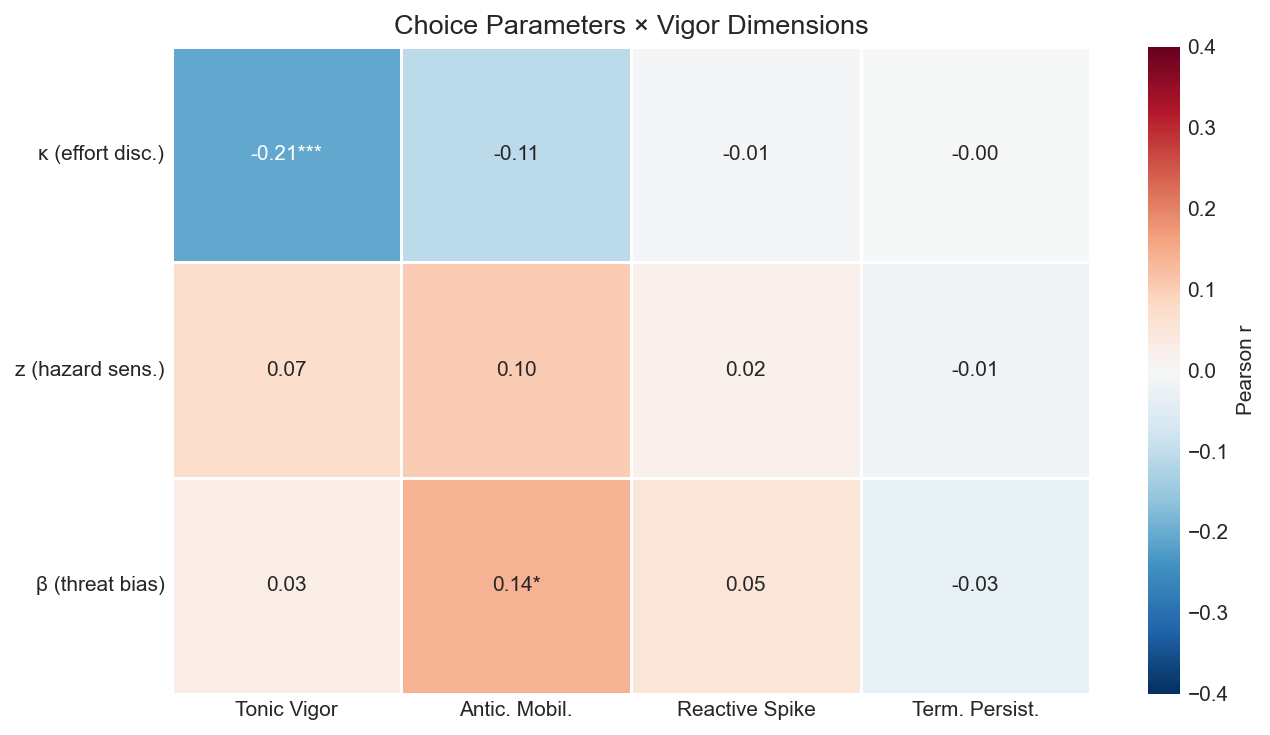

In [3]:
# ── HEATMAP FIGURE ────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5), dpi=DPI)

# Build annotation labels with stars
annot = np.empty((3, 4), dtype=object)
for i in range(3):  # choice params
    for j in range(len(vigor_cols)):
        r = corr_values[i, j]
        p = p_values[i, j]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        annot[i, j] = f'{r:.2f}{stars}'

corr_df = pd.DataFrame(corr_values, index=choice_labels, columns=vigor_labels)

sns.heatmap(corr_df, annot=annot, fmt='', center=0, cmap='RdBu_r',
            vmin=-0.4, vmax=0.4, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
ax.set_title('Choice Parameters × Vigor Dimensions', fontsize=13)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'vigor_nb3_3x3_heatmap.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGS_DIR / 'vigor_nb3_3x3_heatmap.pdf', bbox_inches='tight')
plt.show()

## Section 2: Multiple Regressions

For each vigor dimension, regress on all three choice parameters simultaneously.
R² tells us how much choice explains; residual variance is what vigor adds uniquely.

In [4]:
# ── MULTIPLE REGRESSIONS ──────────────────────────────────────────────────────

reg_results = []

for vc, vl in zip(vigor_cols, vigor_labels):
    formula = f'{vc} ~ kappa_z + z_z + beta_z'
    fit = smf.ols(formula, data=df).fit()

    print(f'\n{"="*60}')
    print(f'{vl}: {formula}')
    print(f'R² = {fit.rsquared:.3f}, Adj. R² = {fit.rsquared_adj:.3f}, '
          f'F({fit.df_model:.0f},{fit.df_resid:.0f}) = {fit.fvalue:.2f}, p = {fit.f_pvalue:.4f}')
    print(f'{"─"*60}')

    for param in ['kappa_z', 'z_z', 'beta_z']:
        b = fit.params[param]
        se = fit.bse[param]
        p = fit.pvalues[param]
        ci = fit.conf_int().loc[param]
        stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else ''
        print(f'  {param:10s}: β={b:+.3f}, SE={se:.3f}, p={p:.4f}{stars:4s}, '
              f'95% CI [{ci[0]:+.3f}, {ci[1]:+.3f}]')

        reg_results.append({
            'vigor_dim': vc, 'vigor_label': vl,
            'predictor': param,
            'beta': b, 'se': se, 'pvalue': p,
            'ci_lower': ci[0], 'ci_upper': ci[1],
            'r_squared': fit.rsquared,
            'adj_r_squared': fit.rsquared_adj,
        })

    # Residual variance = unique vigor contribution
    print(f'\n  Residual variance: {1 - fit.rsquared:.1%} of vigor variance is NOT explained by choice')


Tonic Vigor: tonic_vigor ~ kappa_z + z_z + beta_z
R² = 0.059, Adj. R² = 0.049, F(3,288) = 6.03, p = 0.0005
────────────────────────────────────────────────────────────
  kappa_z   : β=-0.188, SE=0.047, p=0.0001*** , 95% CI [-0.280, -0.096]
  z_z       : β=+0.089, SE=0.046, p=0.0558    , 95% CI [-0.002, +0.180]
  beta_z    : β=+0.045, SE=0.046, p=0.3254    , 95% CI [-0.045, +0.135]

  Residual variance: 94.1% of vigor variance is NOT explained by choice

Antic. Mobil.: anticipatory_mobilization ~ kappa_z + z_z + beta_z
R² = 0.049, Adj. R² = 0.039, F(3,288) = 4.92, p = 0.0024
────────────────────────────────────────────────────────────
  kappa_z   : β=-0.109, SE=0.043, p=0.0118*   , 95% CI [-0.194, -0.024]
  z_z       : β=+0.087, SE=0.043, p=0.0431*   , 95% CI [+0.003, +0.171]
  beta_z    : β=+0.111, SE=0.043, p=0.0094**  , 95% CI [+0.027, +0.195]

  Residual variance: 95.1% of vigor variance is NOT explained by choice

Reactive Spike: reactive_spike ~ kappa_z + z_z + beta_z
R² = 0.003,

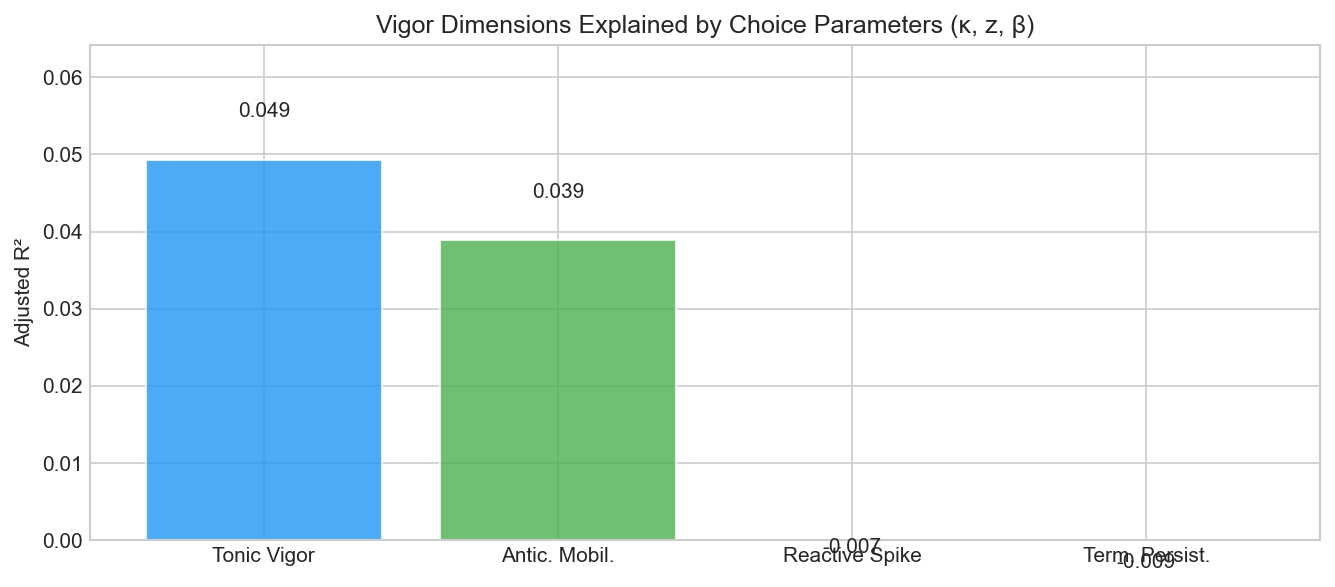

In [5]:
# ── R² BAR CHART ──────────────────────────────────────────────────────────────

r2_vals = []
for vc in vigor_cols:
    fit = smf.ols(f'{vc} ~ kappa_z + z_z + beta_z', data=df).fit()
    r2_vals.append(fit.rsquared_adj)

fig, ax = plt.subplots(figsize=(9, 4), dpi=DPI)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.bar(vigor_labels, r2_vals, color=colors, alpha=0.8, edgecolor='white')

# Add value labels
for bar, r2 in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{r2:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Adjusted R²')
ax.set_title('Vigor Dimensions Explained by Choice Parameters (κ, z, β)')
ax.set_ylim(0, max(max(r2_vals) * 1.3, 0.05))
ax.axhline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.savefig(FIGS_DIR / 'vigor_nb3_r2_bars.png', dpi=300, bbox_inches='tight')
plt.show()

## Section 3: Key Scatter Plots

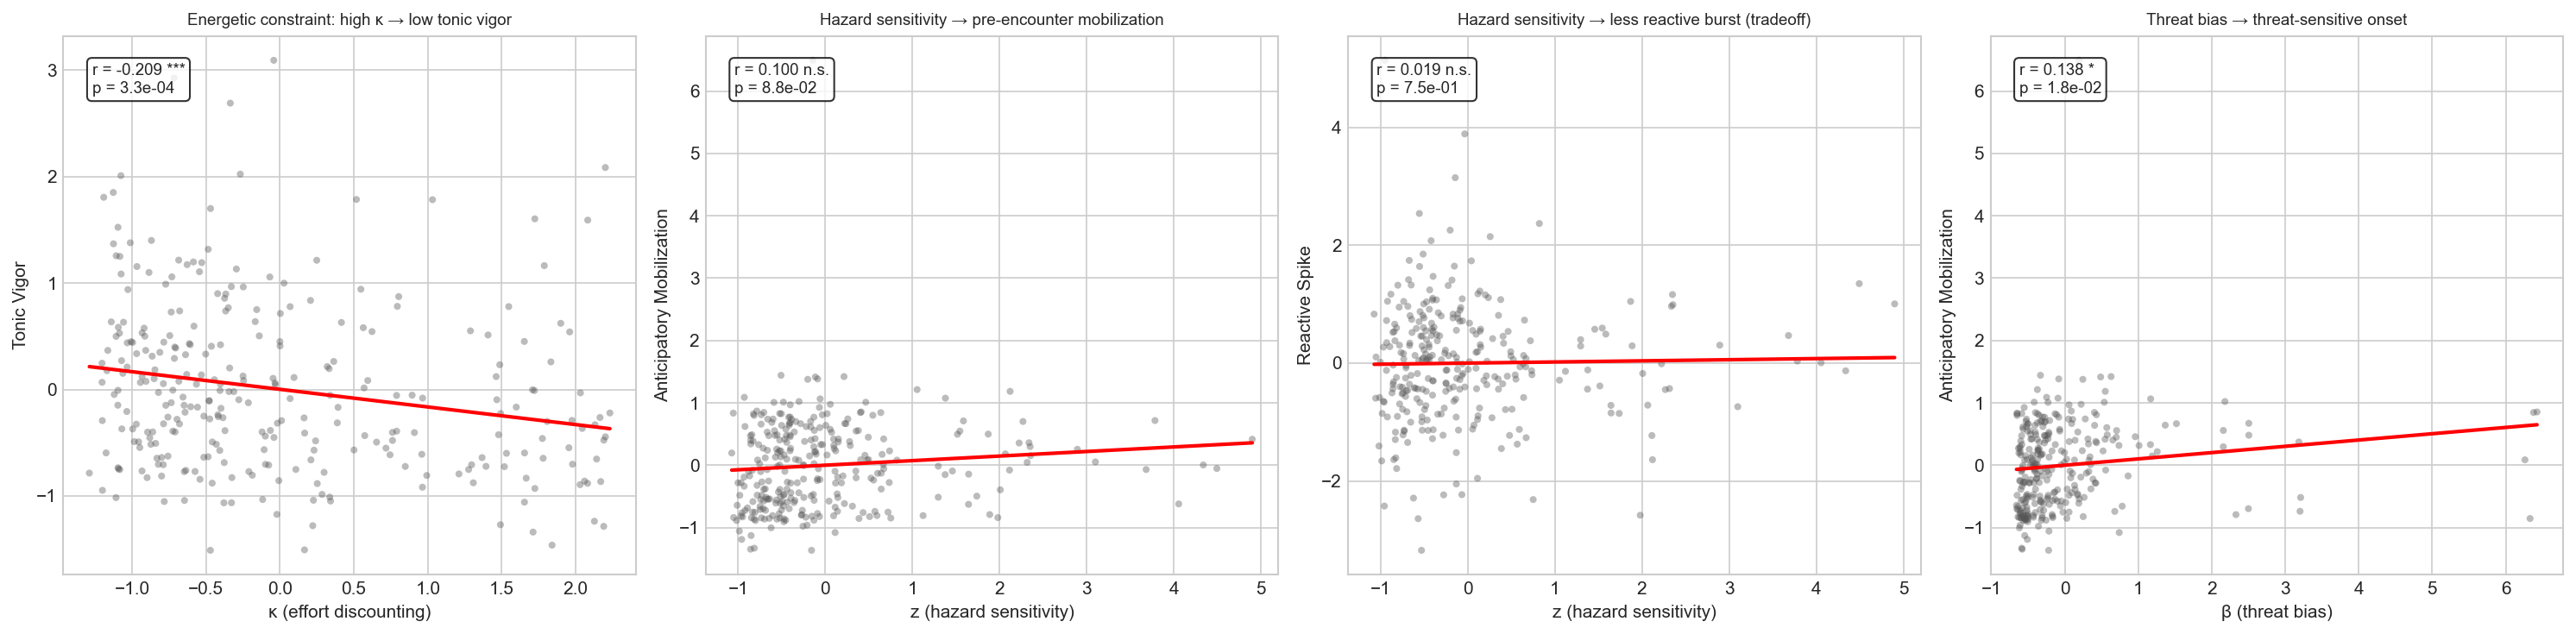

In [6]:
# ── SCATTER PLOTS: KEY PREDICTED ASSOCIATIONS ─────────────────────────────────

scatter_specs = [
    ('kappa_z', 'tonic_vigor',
     'κ (effort discounting)', 'Tonic Vigor',
     'Energetic constraint: high κ → low tonic vigor'),
    ('z_z', 'anticipatory_mobilization',
     'z (hazard sensitivity)', 'Anticipatory Mobilization',
     'Hazard sensitivity → pre-encounter mobilization'),
    ('z_z', 'reactive_spike',
     'z (hazard sensitivity)', 'Reactive Spike',
     'Hazard sensitivity → less reactive burst (tradeoff)'),
    ('beta_z', 'anticipatory_mobilization',
     'β (threat bias)', 'Anticipatory Mobilization',
     'Threat bias → threat-sensitive onset'),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), dpi=DPI)

for ax, (xc, yc, xl, yl, title) in zip(axes, scatter_specs):
    x, y = df[xc], df[yc]
    ax.scatter(x, y, alpha=0.4, s=15, c='#555555', edgecolors='none')

    # Linear fit
    mask = x.notna() & y.notna()
    m, b = np.polyfit(x[mask], y[mask], 1)
    r, p = pearsonr(x[mask], y[mask])
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', linewidth=2)

    stars = '***' if p < .001 else '**' if p < .01 else '*' if p < .05 else 'n.s.'
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title, fontsize=9)
    ax.text(0.05, 0.95, f'r = {r:.3f} {stars}\np = {p:.1e}',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(FIGS_DIR / 'vigor_nb3_scatter.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGS_DIR / 'vigor_nb3_scatter.pdf', bbox_inches='tight')
plt.show()

## Section 4: Save Results

In [7]:
# ── SAVE ──────────────────────────────────────────────────────────────────────

results_df = pd.DataFrame(reg_results)
outpath = RESULTS_DIR / 'choice_vigor_mapping_results.csv'
results_df.to_csv(outpath, index=False)
print(f'Saved {outpath}: {results_df.shape}')

# ── Summary table for manuscript ──
print('\n' + '=' * 80)
print('SUMMARY: Choice–Vigor Mapping')
print('=' * 80)
for vc, vl in zip(vigor_cols, vigor_labels):
    subset = results_df[results_df['vigor_dim'] == vc]
    r2 = subset['adj_r_squared'].iloc[0]
    print(f'\n{vl} (adj. R² = {r2:.3f}):')
    for _, row in subset.iterrows():
        stars = '***' if row['pvalue'] < .001 else '**' if row['pvalue'] < .01 else '*' if row['pvalue'] < .05 else 'n.s.'
        print(f'  {row["predictor"]:10s}: β = {row["beta"]:+.3f} [{row["ci_lower"]:+.3f}, {row["ci_upper"]:+.3f}] '
              f'p = {row["pvalue"]:.4f} {stars}')

Saved /Users/nokada/Desktop/EffortForagingUnderThreat/results/choice_vigor_mapping_results.csv: (12, 10)

SUMMARY: Choice–Vigor Mapping

Tonic Vigor (adj. R² = 0.049):
  kappa_z   : β = -0.188 [-0.280, -0.096] p = 0.0001 ***
  z_z       : β = +0.089 [-0.002, +0.180] p = 0.0558 n.s.
  beta_z    : β = +0.045 [-0.045, +0.135] p = 0.3254 n.s.

Antic. Mobil. (adj. R² = 0.039):
  kappa_z   : β = -0.109 [-0.194, -0.024] p = 0.0118 *
  z_z       : β = +0.087 [+0.003, +0.171] p = 0.0431 *
  beta_z    : β = +0.111 [+0.027, +0.195] p = 0.0094 **

Reactive Spike (adj. R² = -0.007):
  kappa_z   : β = -0.018 [-0.137, +0.101] p = 0.7683 n.s.
  z_z       : β = +0.019 [-0.099, +0.138] p = 0.7462 n.s.
  beta_z    : β = +0.052 [-0.065, +0.170] p = 0.3797 n.s.

Term. Persist. (adj. R² = -0.009):
  kappa_z   : β = +0.006 [-0.099, +0.111] p = 0.9134 n.s.
  z_z       : β = -0.012 [-0.117, +0.092] p = 0.8150 n.s.
  beta_z    : β = -0.029 [-0.132, +0.075] p = 0.5830 n.s.


## Summary

**Key findings:**
- The 3×4 mapping shows how choice parameters relate to distinct vigor dimensions.
- Separating anticipatory mobilization from reactive spike preserves the z crossover.
- The residual variance (1 − R²) quantifies unique information vigor carries beyond choice.

**Expected pattern:**
- κ → negatively predicts tonic vigor (energetic constraint)
- z → positively predicts anticipatory mobilization, negatively predicts reactive spike (tonic-phasic tradeoff)
- β → positively predicts anticipatory mobilization (threat-sensitive onset)

**Next:** NB4 will test whether combining choice parameters and vigor dimensions predicts
psychiatric symptom dimensions better than either alone.